# Senegal Macroeconomic Analysis

This notebook analyzes selected macroeconomic indicators for Senegal using data from the World Bank API.

The objective is to build a structured and reproducible macroeconomic analysis pipeline that retrieves, cleans, transforms, visualizes, and interprets economic data.

The current analysis focuses on GDP through:
- GDP level analysis
- GDP growth rate analysis
- CAGR / TCAM analysis

The project is designed to evolve progressively into a reusable macroeconomic analysis engine for countries available in the World Bank database.

## 1. Import all the required libraries

In [1]:
# First, we will import all the libraries we will need for this project

import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("../"))

from src.data import get_data
from src.cleaning import clean_data
from src.visualization import line_plt, hist_plt, scat_plt, box_plt
from src.indicators import compute_growth_rate, compute_cagr, compute_moving_average


## Utility Modules

Reusable functions are separated into dedicated modules inside `src/`.

- `data.py`: data retrieval from the World Bank API
- `cleaning.py`: missing values and outlier handling
- `visualization.py`: reusable plotting functions
- `indicators.py`: macroeconomic indicator calculations

## 2. Data Collection

Macroeconomic data is retrieved from the World Bank API.

The indicators used in this notebook include:
- GDP (NY.GDP.MKTP.CD)
- Inflation (FP.CPI.TOTL.ZG)

The data is collected for Senegal (SN) over the period 1990–2024.

In [2]:
# Retrieve GDP data for Senegal from the World Bank API

GDP_CODE = 'NY.GDP.MKTP.CD'
INFLATION_CODE = 'FP.CPI.TOTL.ZG'
SENEGAL_CODE = 'SN'

In [3]:
# Here, I will store all the data, in the senegal_gdp_data

senegal_gdp_data = get_data(GDP_CODE, SENEGAL_CODE , 1990, 2024, 1e9, 'GDP (in billions $)')


## 3. Data Cleaning

The data is processed to ensure consistency and usability.

Missing values are removed, and potential outliers are identified using the interquartile range (IQR) method.

In [4]:
#Clean the dataset: remove missing values and detect outliers using IQR
senegal_gdp_data_cleaned, outliers, remove_outlier, missing_values = clean_data(senegal_gdp_data,'GDP (in billions $)')



In [5]:
# Display cleaned dataset
print("=== CLEANED DATA ===")
display(senegal_gdp_data_cleaned.head())

# Display detected outliers
print("\n=== OUTLIERS ===")
display(outliers)

# Summary statistics
print("\n=== NUMBER OF OUTLIERS REMOVED ===")
print(remove_outlier)
print("\n=== MISSING VALUES ===")
print(missing_values)


=== CLEANED DATA ===


,GDP (in billions $)
date,
2024-01-01,32.808057
2023-01-01,30.696331
2022-01-01,27.783332
2021-01-01,27.520784
2020-01-01,24.530513



=== OUTLIERS ===


,GDP (in billions $)
date,



=== NUMBER OF OUTLIERS REMOVED ===
0

=== MISSING VALUES ===
GDP (in billions $)    0
dtype: int64


## 4. Data Visualization and Analysis

This section uses the reusable visualization and indicator functions defined in the `src/` modules to explore the cleaned macroeconomic data.

The objective is to analyze both the level and the dynamics of key indicators, starting with GDP.

The current analysis focuses on:

- GDP level: to observe the long-term evolution of Senegal’s economic output
- GDP growth rate: to measure the annual pace of economic expansion or slowdown
- GDP CAGR: to summarize long-term average annual growth over a selected period

The main modules used in this section are:

- `src.visualization`: plotting functions for time series, distributions, outliers, and relationships
- `src.indicators`: macroeconomic indicator functions such as growth rate and CAGR

### 4.1 GDP Level

This section visualizes Senegal’s GDP in level terms.  
It helps understand the long-term evolution of the size of the economy.

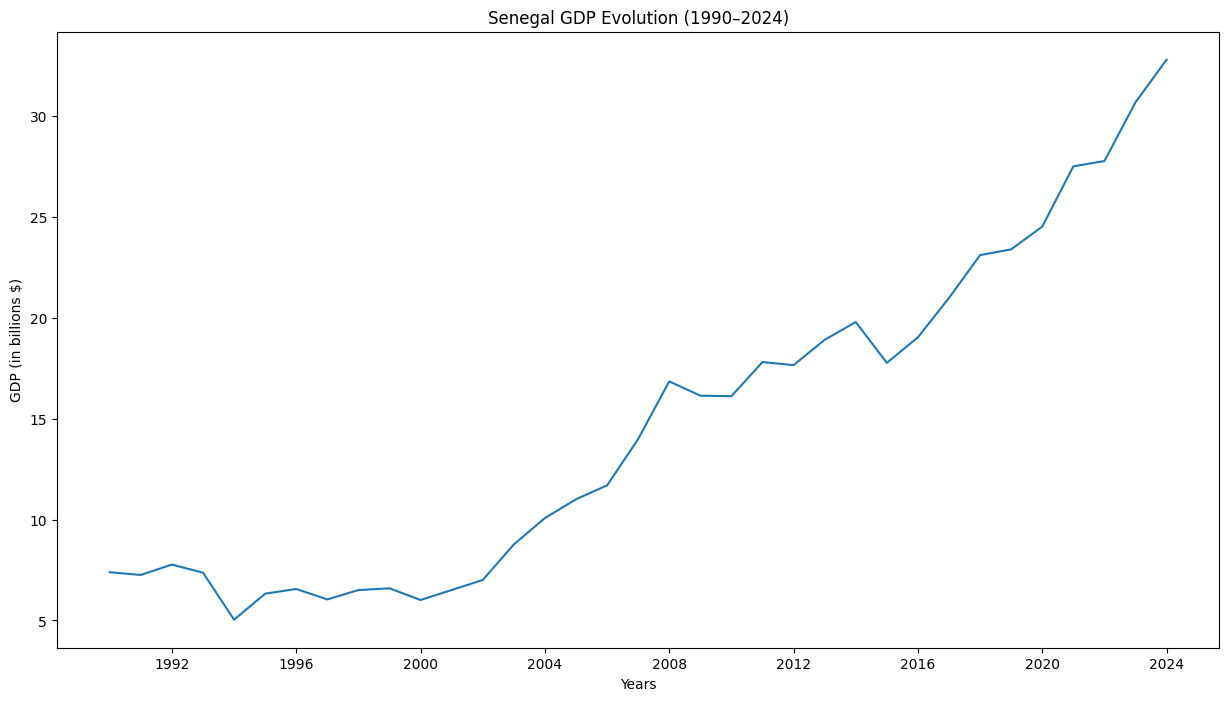

In [6]:
# Visualize GDP level over time to analyze Senegal’s long-term economic growth

line_plt(senegal_gdp_data_cleaned, 'GDP (in billions $)','Years', 'GDP (in billions $)',"Senegal GDP Evolution (1990–2024)")


### Interpretation

Senegal’s GDP shows a clear upward trend over the period 1990–2024, indicating sustained economic growth.

Growth appears to accelerate after the mid-2000s, which may reflect structural economic changes and increased investment.

A temporary slowdown is visible around 2014–2016, followed by a strong recovery and continued expansion.

Overall, the economy demonstrates long-term resilience with increasing output levels.

### 4.2 GDP Growth Rate

The GDP growth rate measures the annual percentage change in GDP.  
It helps identify periods of acceleration, slowdown, or contraction in economic activity.


=== DATA WITH GDP GROWTH RATE ===


,GDP (in billions $),GDP Growth Rate (%)
date,,
1990-01-01,7.390967,NaN
1991-01-01,7.255210,-1.836795
1992-01-01,7.769818,7.092935
1993-01-01,7.367986,-5.171699
1994-01-01,5.034588,-31.669414


,GDP (in billions $),GDP Growth Rate (%)
date,,
2020-01-01,24.530513,4.813353
2021-01-01,27.520784,12.190006
2022-01-01,27.783332,0.953999
2023-01-01,30.696331,10.484700
2024-01-01,32.808057,6.879406


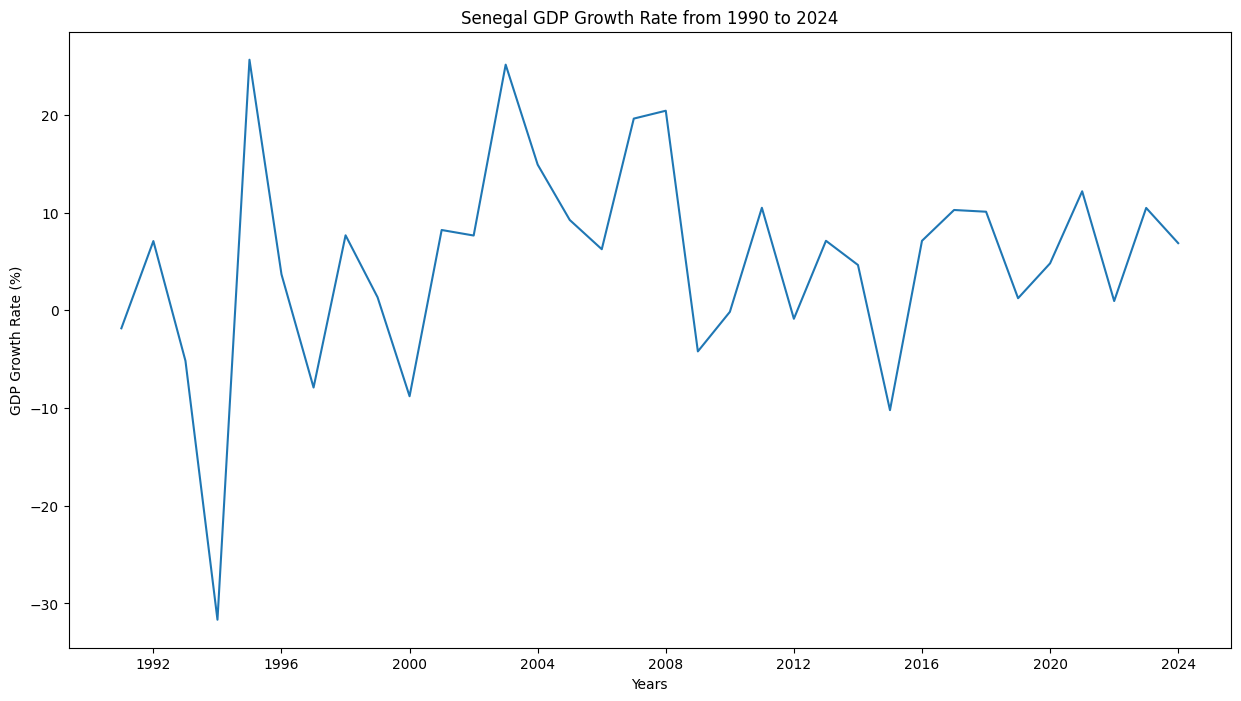

In [7]:
# Compute GDP growth rate
senegal_gdp_growth = compute_growth_rate(senegal_gdp_data_cleaned, 'GDP (in billions $)', 'GDP Growth Rate (%)' )
# Display the dataset with the new growth rate column
print("\n=== DATA WITH GDP GROWTH RATE ===")
display(senegal_gdp_growth.head())
display(senegal_gdp_growth.tail())

# Visualize GDP growth rate over time to analyze Senegal’s economic growth dynamics
line_plt(senegal_gdp_growth, 'GDP Growth Rate (%)','Years', 'GDP Growth Rate (%)', "Senegal GDP Growth Rate from 1990 to 2024")

### Interpretation

The GDP growth rate shows stronger volatility than GDP in level terms.  
Positive values indicate periods of economic expansion, while negative values indicate contractions or slowdowns.

The large fluctuations in the early 1990s suggest that Senegal’s economic growth was unstable during that period.  
From the 2000s onward, growth appears more consistently positive, although some slowdowns remain visible.

### 4.3 GDP CAGR

The Compound Annual Growth Rate (CAGR) measures the average annual growth rate of GDP over a selected period.

Unlike the annual GDP growth rate, which shows year-to-year changes, CAGR summarizes long-term growth into one annualized percentage.

In [8]:
# Compute GDP CAGR over the selected period
cagr = compute_cagr(senegal_gdp_growth, 'GDP (in billions $)', 1990, 2024)
print(f"\n=== GDP CAGR from 1990 to 2024 ===\n{cagr:.2f}%")


=== GDP CAGR from 1990 to 2024 ===
4.48%


### Interpretation

The GDP CAGR summarizes Senegal’s average annual GDP growth over the period 1990–2024.

Unlike the yearly GDP growth rate, which can fluctuate from one year to another, the CAGR provides a long-term view of the economy’s average expansion pace.

A positive CAGR indicates that Senegal’s GDP increased on average each year over the selected period. However, it does not show short-term volatility or economic shocks, which are better captured by the annual GDP growth rate.

### 4.4 GDP Growth Moving Average

The moving average smooths short-term fluctuations in GDP growth and highlights the medium-term growth trend.

In [29]:
# Compute a 3-year moving average to smooth GDP growth fluctuations
senegal_gdp_growth_ma = compute_moving_average(senegal_gdp_growth,"GDP Growth Rate (%)",3)

# Display the dataset with the new moving average column
display(senegal_gdp_growth_ma.head(40))

,GDP (in billions $),GDP Growth Rate (%),GDP Growth Rate (%) 3Y MA
date,,,
1990-01-01,7.390967,NaN,NaN
1991-01-01,7.255210,-1.836795,NaN
1992-01-01,7.769818,7.092935,NaN
1993-01-01,7.367986,-5.171699,0.028147
1994-01-01,5.034588,-31.669414,-9.916059
1995-01-01,6.326343,25.657599,-3.727838
1996-01-01,6.559712,3.688854,-0.774320
1997-01-01,6.041479,-7.900247,7.148735
1998-01-01,6.505608,7.682377,1.156995


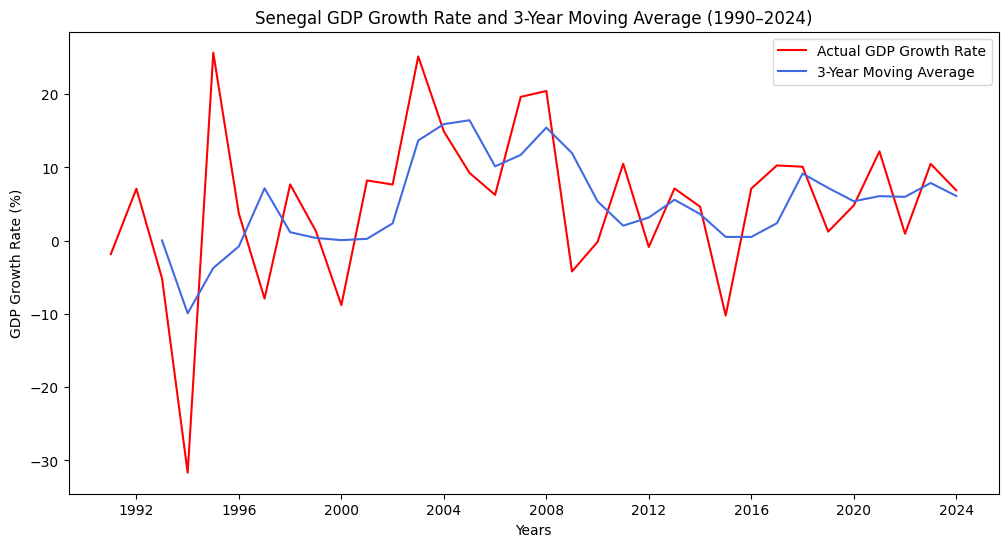

In [27]:
# Plot actual GDP growth and its 3-year moving average on the same chart
plt.figure(figsize=(12, 6))

# Plot the annual GDP growth rate
ax1 = sns.lineplot(
    data=senegal_gdp_growth_ma,
    x="date",
    y="GDP Growth Rate (%)",
    label="Actual GDP Growth Rate",
    color="red"
)

# Plot the smoothed GDP growth trend using the 3-year moving average
ax2 = sns.lineplot(
    data=senegal_gdp_growth_ma,
    x="date",
    y="GDP Growth Rate (%) 3Y MA",
    label="3-Year Moving Average",
    color="royalblue"
)

# Add chart title, axis labels, and legend
ax1.set_title("Senegal GDP Growth Rate and 3-Year Moving Average (1990–2024)")
ax1.set_xlabel("Years")
ax1.set_ylabel("GDP Growth Rate (%)")
ax1.legend()

plt.show()

### Interpretation

The annual GDP growth rate shows strong year-to-year fluctuations, with sharp drops and temporary spikes.

The 3-year moving average provides a clearer view of the underlying trend by smoothing short-term volatility. It reduces the visual impact of large one-year drops and puts temporary growth spikes into perspective.

This makes it easier to identify Senegal’s medium-term growth dynamics and assess whether growth is becoming more stable, accelerating, or slowing down over time.

## 5. Summary

This notebook follows a structured macroeconomic analysis pipeline:

1. Data retrieval from the World Bank API  
2. Data cleaning and preprocessing  
3. Macroeconomic indicator computation  
4. Data visualization and interpretation  

The current analysis focuses on Senegal’s GDP through three complementary perspectives:

- GDP level: shows the long-term evolution of economic output  
- GDP growth rate: measures year-to-year economic expansion or slowdown  
- GDP CAGR: summarizes the average annual growth rate over the selected period  

The project is now structured around reusable modules:

- `src.data` for data retrieval  
- `src.cleaning` for preprocessing  
- `src.visualization` for plotting  
- `src.indicators` for macroeconomic indicators  

This modular structure makes the project easier to maintain, extend, and reuse for other countries or indicators available in the World Bank database.